In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('events.csv')
df['price_num'] = df['price'].apply(lambda x: 0 if str(x).lower() == 'free' else float(x))
df['soup'] = (df['category'].fillna('') + ' ' + df['category'].fillna('') + ' ' +
              df['subcategory'].fillna('') + ' ' + df['tags'].fillna('') + ' ' +
              df['tags'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['soup'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
ALL_CATEGORIES = sorted(df['category'].unique().tolist())
print(f' {len(df)} events is load sucessfully!')
print(f' Available categories: {ALL_CATEGORIES}')

 20 events is load sucessfully!
 Available categories: ['Art', 'Comedy', 'Festival', 'Food', 'Literature', 'Music', 'Sports', 'Technology', 'Theatre', 'Wellness']


In [3]:

print('    WELCOME TO EVENT RECOMMENDER!')
print('=' * 50)
print()


user_name = input('What is yout name? --> ').strip() or 'friend'
print(f'\n Hello {user_name}! lets ask some questions...\n')

print('Which category you like?')
for i, cat in enumerate(ALL_CATEGORIES, 1):
    print(f'   {i}. {cat}')
print(f'   {len(ALL_CATEGORIES)+1}. Anything is fine (No preference)')
while True:
    try:
        cat_choice = int(input(f' choose a Number  (1-{len(ALL_CATEGORIES)+1}): --> '))
        if 1 <= cat_choice <= len(ALL_CATEGORIES) + 1:
            break
        print('Enter correct number!')
    except ValueError:
        print('Only enter number!')
user_category = ALL_CATEGORIES[cat_choice - 1] if cat_choice <= len(ALL_CATEGORIES) else None


print('\n What is your maximum budget ? (₹ mein, 0 = free only, 999999 = no limit)')
while True:
    try:
        user_budget = float(input('Budget (₹): --> '))
        if user_budget >= 0:
            break
        print('Enter 0 or more!')
    except ValueError:
        print('Only enter number!')


print('\n Any password? (e.g. outdoor, dance, fitness) — Enter skip ')
user_keyword = input('Keyword: --> ').strip().lower()


while True:
    try:
        top_n = int(input('\n how many item recommend? (1-10): --> '))
        if 1 <= top_n <= 10:
            break
        print(' Enter between 1 se 10!')
    except ValueError:
        print('Only enter number!')

print('\n for the input run the next cell!')

    WELCOME TO EVENT RECOMMENDER!



What is yout name? -->  k



 Hello k! lets ask some questions...

Which category you like?
   1. Art
   2. Comedy
   3. Festival
   4. Food
   5. Literature
   6. Music
   7. Sports
   8. Technology
   9. Theatre
   10. Wellness
   11. Anything is fine (No preference)


 choose a Number  (1-11): -->  6



 What is your maximum budget ? (₹ mein, 0 = free only, 999999 = no limit)


Budget (₹): -->  100000



 Any password? (e.g. outdoor, dance, fitness) — Enter skip 


Keyword: -->  

 how many item recommend? (1-10): -->  3



 for the input run the next cell!


In [4]:

filtered = df.copy()
if user_category:
    filtered = filtered[filtered['category'].str.lower() == user_category.lower()]
filtered = filtered[filtered['price_num'] <= user_budget]
if user_keyword:
    filtered = filtered[filtered['soup'].str.contains(user_keyword, na=False)]

print('=' * 60)
print(f'  TOP {top_n} RECOMMENDATIONS for {user_name} ')
print('=' * 60)
print(f'  Category: {user_category or "Any"} | Budget: ₹{int(user_budget)} | Keyword: "{user_keyword or "None"}"')
print('=' * 60)

if filtered.empty:
    print('\n not found any items!')
    print(' Tip: increse your bugget "No preference" choose any.')
else:
    result = filtered.head(top_n).copy()
    for i, (_, row) in enumerate(result.iterrows(), 1):
        price_str = f"₹{row['price']}" if str(row['price']).lower() != 'free' else ' FREE'
        print(f"\n  {i}.  {row['event_name']}")
        print(f"       {row['category']} — {row['subcategory']}")
        print(f"      {row['venue']}")
        print(f"      {row['date']}  |   {price_str}")
    print('\n' + '=' * 60)

  TOP 3 RECOMMENDATIONS for k 
  Category: Music | Budget: ₹100000 | Keyword: "None"

  1.  Coldplay World Tour
       Music — Rock Concert
      GMDC Ground
      2026-05-10  |   ₹2500

  2.  Sufi Night - Kailash Kher
       Music — Sufi
      Tagore Hall
      2026-05-25  |   ₹1000

  3.  DJ Night - Sunburn Festival
       Music — EDM
      GMDC Ground
      2026-12-01  |   ₹3000



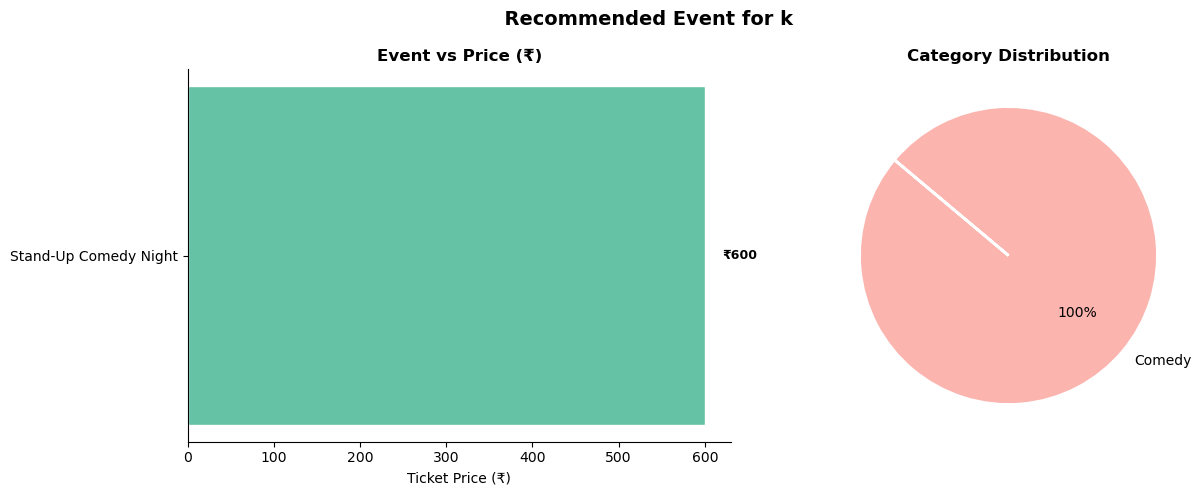

In [6]:

if not filtered.empty:
    result = filtered.head(top_n).copy()
    result['label'] = result['event_name'].apply(lambda x: x[:22] + '…' if len(x) > 22 else x)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"  Recommended Event for {user_name} ", fontsize=14, fontweight='bold')

    colors = plt.cm.Set2(np.linspace(0, 1, len(result)))
    axes[0].barh(result['label'][::-1], result['price_num'][::-1], color=colors, edgecolor='white', height=0.6)
    for bar, val in zip(axes[0].patches, result['price_num'][::-1]):
        label = '₹' + str(int(val)) if val > 0 else 'FREE'
        axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=9, fontweight='bold')
    axes[0].set_title('Event vs Price (₹)', fontweight='bold')
    axes[0].set_xlabel('Ticket Price (₹)')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    cat_counts = result['category'].value_counts()
    axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.0f%%', startangle=140,
                colors=plt.cm.Pastel1.colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Category Distribution', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [7]:


print('Al event list:')
for i, name in enumerate(df['event_name'].tolist(), 1):
    print(f'  {i:2}. {name}')

print()
seed_input = input(' Write any event name (similar events dhundenge) --> ').strip()

match = df[df['event_name'].str.lower().str.contains(seed_input.lower(), na=False)]

if match.empty:
    print(f' "{seed_input}" Not Found. Copy at the uper list .')
else:
    seed_idx  = match.index[0]
    seed_name = df.loc[seed_idx, 'event_name']
    sim_scores = sorted(enumerate(cosine_sim[seed_idx]), key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != seed_idx][:5]

    print()
    print('=' * 60)
    print(f'   "{seed_name}" Like top 5 Recommendation:')
    print('=' * 60)
    for rank, (idx, score) in enumerate(sim_scores, 1):
        row = df.iloc[idx]
        price_str = f"₹{row['price']}" if str(row['price']).lower() != 'free' else ' FREE'
        print(f"\n  {rank}.  {row['event_name']}  (Match: {score:.0%})")
        print(f"       {row['category']} — {row['subcategory']}")
        print(f"      {row['venue']} |  {row['date']} |  {price_str}")
    print('\n' + '=' * 60)

Al event list:
   1. Coldplay World Tour
   2. Navratri Mahotsav
   3. IPL Match - GT vs MI
   4. Stand-Up Comedy Night
   5. Tech Summit 2026
   6. Half Marathon Ahmedabad
   7. Sufi Night - Kailash Kher
   8. Food Festival 2026
   9. Art Exhibition - Modern India
  10. Badminton Championship
  11. DJ Night - Sunburn Festival
  12. Yoga & Wellness Retreat
  13. Gujarati Theatre Festival
  14. Startup Pitch Competition
  15. Kite Festival - Uttarayan
  16. Photography Walk - Old City
  17. Chess Tournament Open
  18. Classical Dance Evening
  19. Thriller Night Book Fair
  20. Rock Climbing Workshop



 Write any event name (similar events dhundenge) -->  20



   "Tech Summit 2026" Like top 5 Recommendation:

  1.  Startup Pitch Competition  (Match: 37%)
       Technology — Startup
      IIMA Campus |  2026-06-28 |   FREE

  2.  Art Exhibition - Modern India  (Match: 1%)
       Art — Exhibition
      Amdavad ni Gufa |  2026-05-15 |  ₹150

  3.  Gujarati Theatre Festival  (Match: 1%)
       Theatre — Drama
      Natarani Amphitheatre |  2026-07-10 |  ₹350

  4.  Coldplay World Tour  (Match: 0%)
       Music — Rock Concert
      GMDC Ground |  2026-05-10 |  ₹2500

  5.  Navratri Mahotsav  (Match: 0%)
       Festival — Cultural
      Sardar Patel Stadium |  2026-10-02 |  ₹500

